In [1]:
import pandas as pd
from pandas.plotting import scatter_matrix
import sqlite3

connection=sqlite3.connect('../data/checking-logs.sqlite')

In [20]:
query = '''
SELECT p.uid, AVG((strftime('%s', t.first_commit_ts) - d.deadlines) / 3600.0) AS avg_diff,
    COUNT(DISTINCT p.datetime) AS pageviews, COUNT(DISTINCT c.timestamp) AS num_commits
FROM pageviews p
LEFT JOIN checker c ON p.uid = c.uid AND c.labname != 'project1'
LEFT JOIN test t ON p.uid = t.uid AND t.labname != 'project1'
LEFT JOIN deadlines d ON t.labname = d.labs
WHERE p.uid LIKE 'user_%'
GROUP BY p.uid
HAVING num_commits>0
'''

df = pd.read_sql(sql=query, con=connection)
df

,uid,avg_diff,pageviews,num_commits
0,user_1,-65.119778,28,62
1,user_10,-75.242444,89,20
2,user_14,-159.568796,143,61
3,user_17,-62.207667,47,51
4,user_18,-6.368148,3,5
5,user_19,-99.440417,16,118
6,user_21,-96.111181,10,65
7,user_25,-93.474944,179,79
8,user_28,-86.793833,149,60
9,user_3,-105.738222,317,18


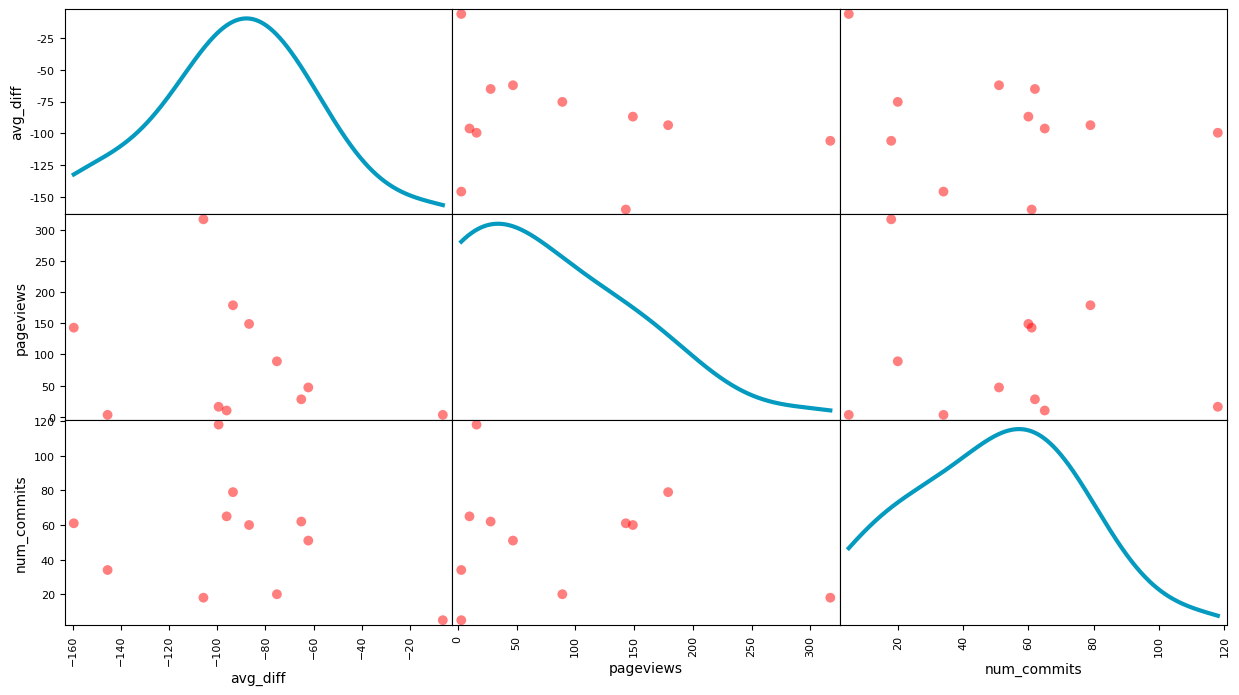

In [21]:
ax = scatter_matrix(
    df,
    figsize=(15, 8),
    diagonal='kde',
    density_kwds=dict(color='#059ABF', linewidth=3),
    s=200,
    color='red'
)

Ниже график без критерия commits>0

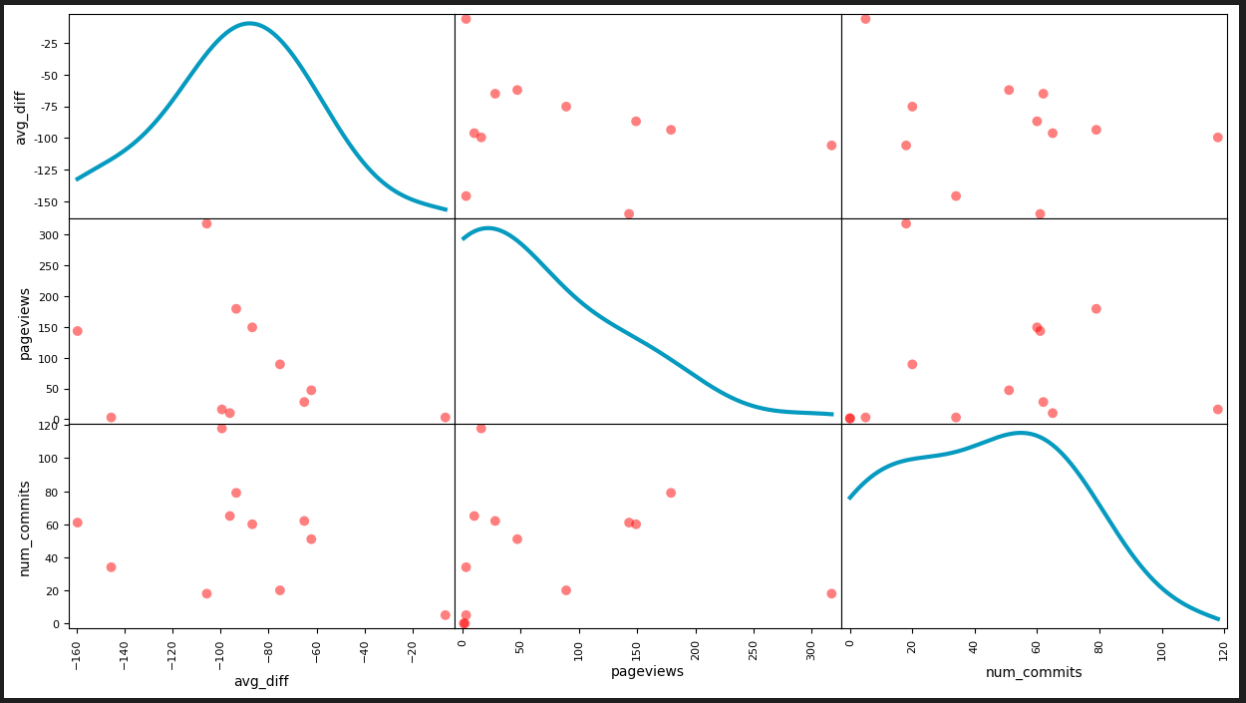

In [22]:
connection.close()

"Можем ли мы сказать, что если у пользователя мало просмотров страниц, то у него, вероятно, мало коммитов?" Ответ "да" или "нет". **Нет**  

"Можем ли мы сказать, что если у пользователя небольшое количество просмотров страниц, то у него, вероятно, небольшая средняя разница между первой фиксацией и крайним сроком лабораторной работы?" Ответ "да" или "нет". **Нет**  

"Можем ли мы сказать, что есть много пользователей с низким количеством коммитов и несколько с большим количеством коммитов?" Ответ "да" или "нет". **Да**  

"Можем ли мы сказать, что есть много пользователей с небольшой средней разницей и несколько с большой средней разницей?" Ответ "да" или "нет". **Нет**  